In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, precision_score, recall_score, f1_score,confusion_matrix,make_scorer,classification_report,roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.shape

(7043, 21)

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [25]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [26]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [27]:
#Drop the rows where TotalCharges is empty and convert the column to numeric

df.drop(df[df["TotalCharges"] == " "].index, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'].dtype

dtype('float64')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

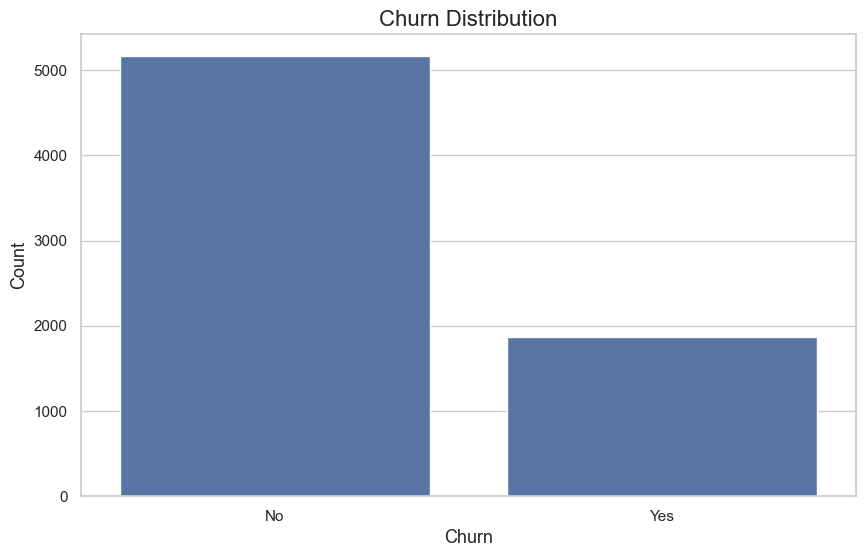

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Insight

- The dataset is imbalanced.
- Most customers did not churn.
- Accuracy alone may not be sufficient for evaluating the model.
- Additional metrics such as Precision, Recall, and F1-score should also be considered.

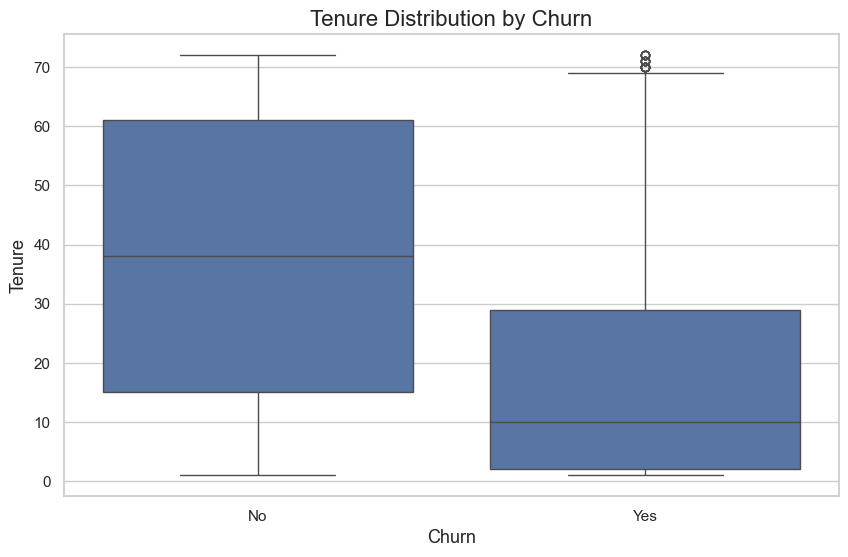

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

### Insight

- Customers who churn generally have much shorter tenure.
- Long-term customers are less likely to leave the company.
- Tenure appears to be an important feature for predicting churn.

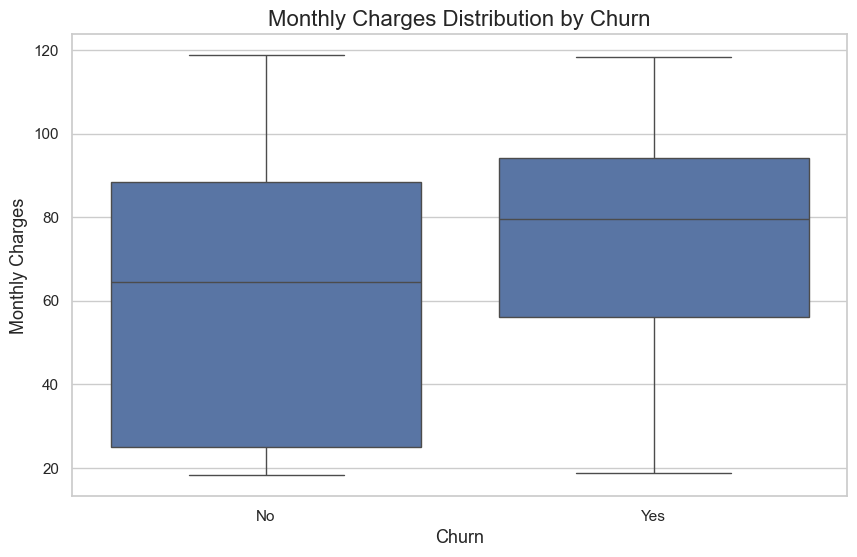

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Insight

- Customers who churn tend to have higher monthly charges.
- Higher monthly charges may be associated with a higher likelihood of churn.

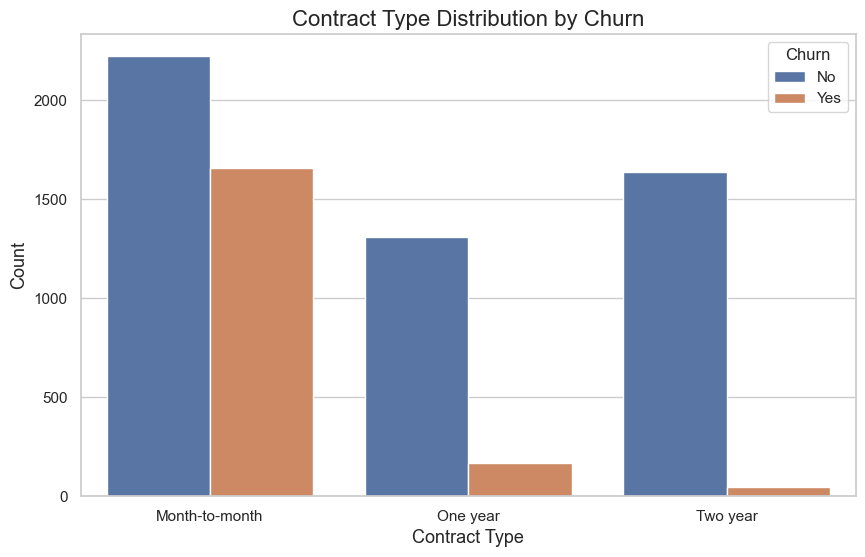

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type Distribution by Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

### Insight

- Customers with month-to-month contracts have the highest churn rate.
- Customers with one-year and two-year contracts are much less likely to churn.
- Contract type appears to be a strong predictor of customer churn.


In [33]:
(
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
)

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.722826
                Yes      11.277174
Two year        No       97.151335
                Yes       2.848665
Name: Rate, dtype: float64

### Insight

- Customers with month-to-month contracts have the highest churn rate (42.7%).
- The churn rate drops significantly for one-year contracts (11.3%).
- Customers with two-year contracts have the lowest churn rate (2.9%).
- Longer contract durations appear to improve customer retention.

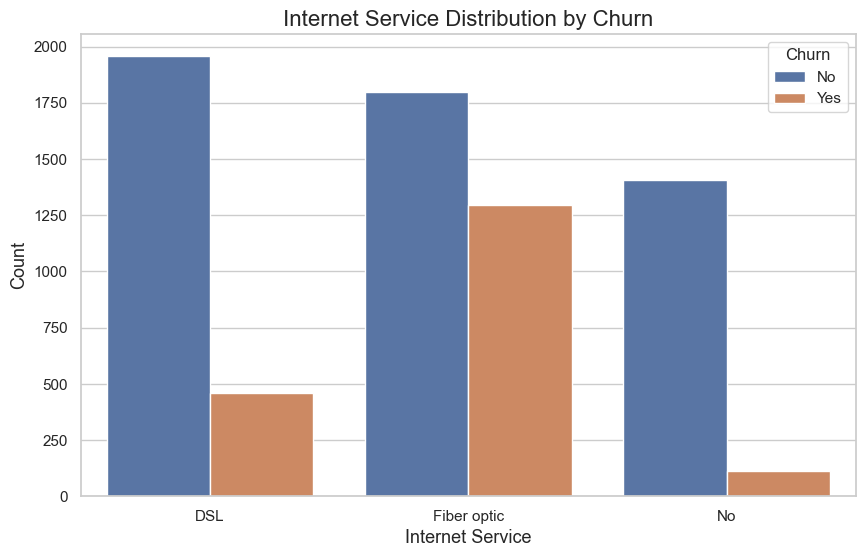

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service Distribution by Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

### Insight

- Customers using Fiber optic internet appear to churn more frequently than DSL customers.
- Customers without internet service have the lowest churn rate.


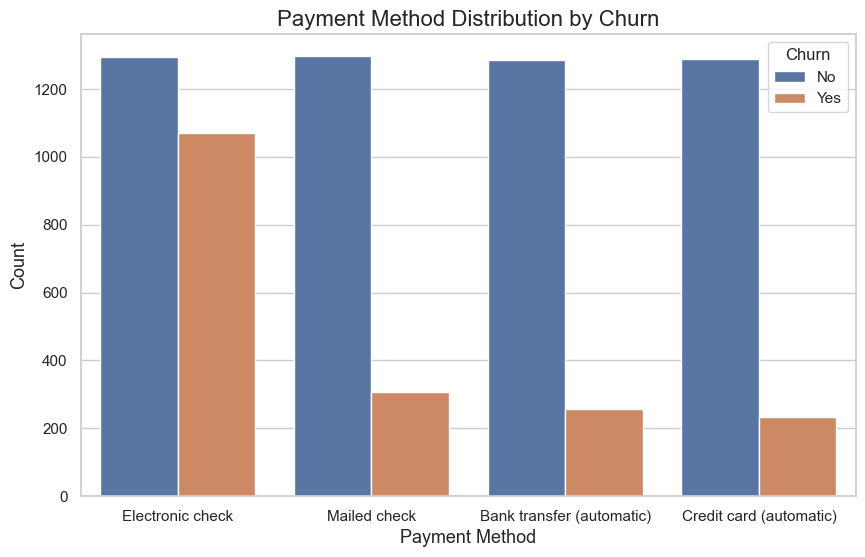

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Payment Method Distribution by Churn")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [36]:
(
    df.groupby("PaymentMethod")["Churn"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.268482
                           Yes      16.731518
Credit card (automatic)    No       84.746877
                           Yes      15.253123
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.798005
                           Yes      19.201995
Name: Rate, dtype: float64

### Insight

- Customers who pay using Electronic Check have the highest churn rate (~45%).
- Customers using automatic payment methods (Bank Transfer and Credit Card) have significantly lower churn rates (~15–17%).
- Automatic payment methods appear to be associated with better customer retention.

In [37]:
df = df.drop(['customerID'], axis=1)

In [38]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [39]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_columns = ["SeniorCitizen"]
categorical_features = x.select_dtypes(include=['object']).columns.tolist()
print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)
print("Binary Columns:", binary_columns)


Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Binary Columns: ['SeniorCitizen']


In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
transformer = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(drop='first'), categorical_features),
        ("binary", "passthrough", binary_columns)
    ]
)

In [42]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42,max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,n_jobs=-1)
}
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", transformer),
        ("model", model)
    ])

    # Train
    pipeline.fit(x_train, y_train)

    # Prediction on Training Data
    y_train_pred = pipeline.predict(x_train)

    # Prediction on Testing Data
    y_test_pred = pipeline.predict(x_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Cross Validation
    cv_score = cross_val_score(
        pipeline,
        x,
        y,
        cv=10,
        scoring="accuracy"
    )

    # Save Results
    results.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision_score(y_test, y_test_pred, pos_label="Yes"),
        "Recall": recall_score(y_test, y_test_pred, pos_label="Yes"),
        "F1 Score": f1_score(y_test, y_test_pred, pos_label="Yes"),
        "CV Accuracy": cv_score.mean(),
        "CV Std": cv_score.std()
    })

In [43]:
results_df = (
    pd.DataFrame(results).sort_values(by="CV Accuracy",ascending=False).reset_index(drop=True)
).round(4)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,CV Accuracy,CV Std
0,Logistic Regression,0.8091,0.7868,0.6194,0.5134,0.5614,0.8042,0.0100
1,Random Forest,0.8663,0.7875,0.6335,0.4759,0.5435,0.8022,0.0170
2,SVM,0.8158,0.7910,0.6471,0.4706,0.5449,0.8011,0.0128
3,Decision Tree,0.8030,0.7754,0.5755,0.5909,0.5831,0.7881,0.0143
4,KNN,0.8668,0.7456,0.5213,0.5241,0.5227,0.7561,0.0178


In [44]:
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "model__max_depth": [3, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, 15],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    }

}

In [45]:
grid_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", transformer),
        ("model", model)
    ])

    f1 = make_scorer(f1_score, pos_label="Yes")

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=10,
        scoring=f1,
        n_jobs=-1,
        error_score="raise"
    )

    grid.fit(x_train, y_train)

    y_train_pred = grid.predict(x_train)
    y_test_pred = grid.predict(x_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    grid_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV F1": grid.best_score_,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

In [46]:
grid_results_df = pd.DataFrame(grid_results).round(4)

grid_results_df

,Model,Best Params,Best CV F1,Train Accuracy,Test Accuracy
0,Logistic Regression,"{'model__C': 10, 'model__solver': 'lbfgs'}",0.6020,0.8089,0.7882
1,KNN,"{'model__n_neighbors': 15, 'model__weights': '...",0.5866,0.8162,0.7733
2,SVM,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.5972,0.8030,0.7946
3,Decision Tree,"{'model__max_depth': 5, 'model__min_samples_le...",0.5810,0.8027,0.7754
4,Random Forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.5905,0.8677,0.7925


In [47]:
best_model = max(
    grid_results,
    key=lambda x: x["Best CV F1"]
)

best_model

{'Model': 'Logistic Regression',
 'Best Params': {'model__C': 10, 'model__solver': 'lbfgs'},
 'Best CV F1': np.float64(0.6020472388773983),
 'Train Accuracy': 0.8088888888888889,
 'Test Accuracy': 0.7882018479033405}

In [48]:
best_pipeline = Pipeline([
    ("preprocessor", transformer),
    ("model", LogisticRegression(
        C=10,
        solver="lbfgs",
        random_state=42
    ))
])

best_pipeline.fit(x_train, y_train)

y_prob = best_pipeline.predict_proba(x_test)[:, 1]
y_pred = (y_prob >= 0.4).astype(int)
y_pred = ["Yes" if i == 1 else "No" for i in y_pred]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Yes"))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7810945273631841
Precision: 0.5793269230769231
Recall   : 0.6443850267379679
F1 Score : 0.610126582278481

Classification Report

              precision    recall  f1-score   support

          No       0.87      0.83      0.85      1033
         Yes       0.58      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



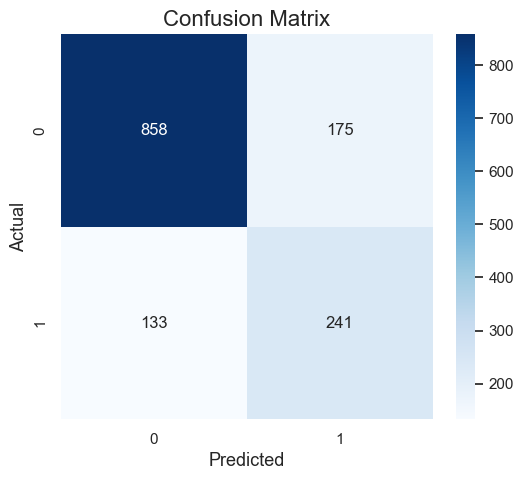

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

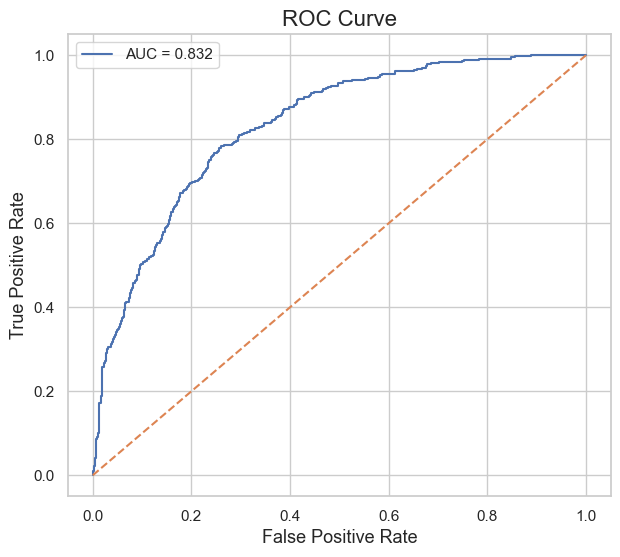

ROC AUC Score : 0.8317915215016747


In [50]:
y_prob = best_pipeline.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("ROC AUC Score :", roc_auc_score(y_test, y_prob))

In [51]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_pipeline.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance.head(20)

,Feature,Coefficient
9,categorical__InternetService_Fiber optic,1.883624
0,numeric__tenure,-1.494711
24,categorical__Contract_Two year,-1.342347
1,numeric__MonthlyCharges,-1.339344
7,categorical__MultipleLines_No phone service,-0.952507
23,categorical__Contract_One year,-0.770689
2,numeric__TotalCharges,0.745954
6,categorical__PhoneService_Yes,-0.694217
22,categorical__StreamingMovies_Yes,0.686826
20,categorical__StreamingTV_Yes,0.667180


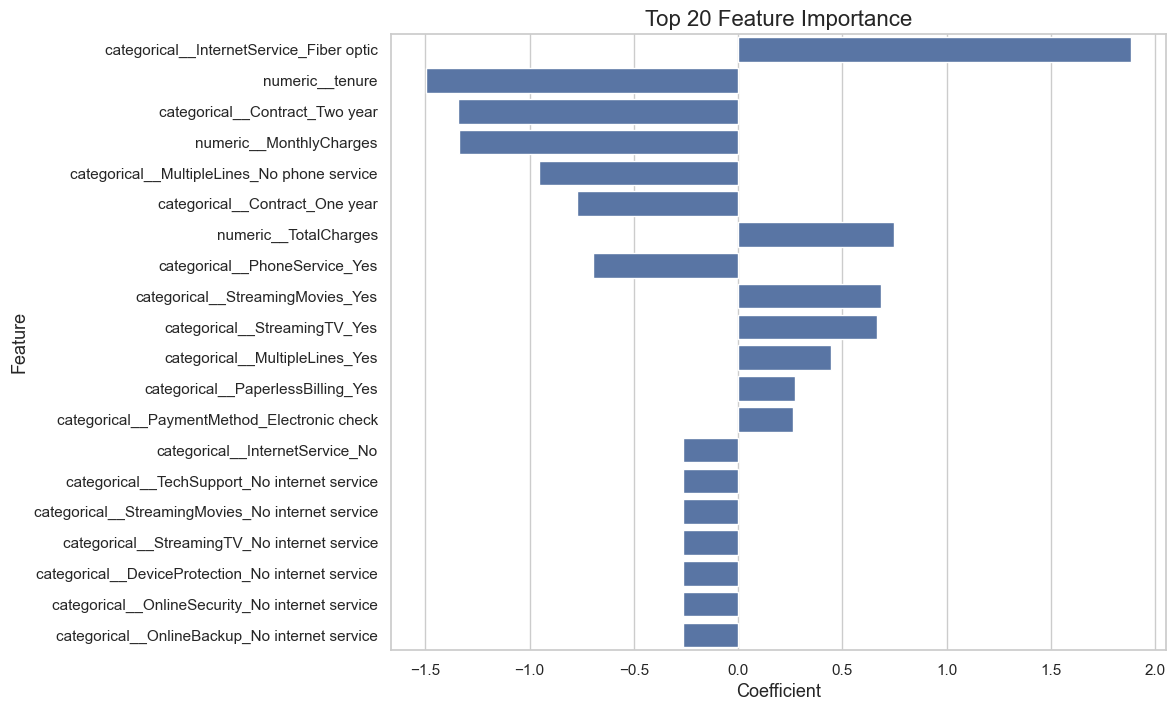

In [52]:
plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(20),x="Coefficient",y="Feature")
plt.title("Top 20 Feature Importance")
plt.show()

# Neural Network


In [53]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({'No': 0, 'Yes': 1}).astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [54]:
NN_model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [55]:
NN_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = NN_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,verbose=1,callbacks=[early_stop])

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7353 - loss: 0.5637 - val_accuracy: 0.7938 - val_loss: 0.4499
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7911 - loss: 0.4647 - val_accuracy: 0.7964 - val_loss: 0.4233
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7878 - loss: 0.4438 - val_accuracy: 0.8000 - val_loss: 0.4179
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7873 - loss: 0.4356 - val_accuracy: 0.7947 - val_loss: 0.4132
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7971 - loss: 0.4323 - val_accuracy: 0.7956 - val_loss: 0.4141
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8013 - loss: 0.4288 - val_accuracy: 0.8000 - val_loss: 0.4138
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7989 - loss: 0.4281 - val_accuracy: 0.8000 - val_loss: 0.4101
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4222 - val_accu

In [57]:
test_loss, test_acc = NN_model.evaluate(X_test, y_test, verbose=1)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7861 - loss: 0.4304 
Test accuracy: 0.7860696315765381
Test loss: 0.43037310242652893


In [58]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for i in range(4):
    y_pred = NN_model.predict(X_test)
    y_pred = (y_pred > thresholds[i]).astype(int)

    print(f"Threshold: {thresholds[i]}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.3
[[776 257]
 [ 91 283]]
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82      1033
         1.0       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.76      1407

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Threshold: 0.4
[[874 159]
 [149 225]]
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1033
         1.0       0.59      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Threshold: 0.5
[[919 114]
 [187 187]]
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1033
    

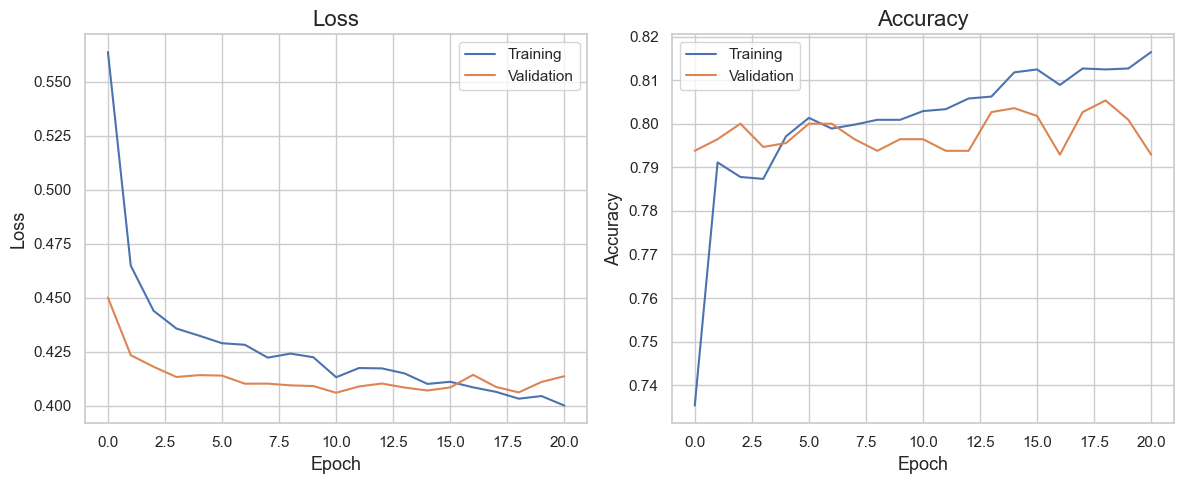

In [59]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [60]:
NN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,997 (19.52 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,332 (13.02 KB)

# Business Insights

- Customers with month-to-month contracts are significantly more likely to churn.

- Long-term customers are much less likely to churn.

- Customers paying via Electronic Check have the highest churn rate.

- Fiber optic customers show a higher churn rate than DSL customers.

- Customers with higher monthly charges are more likely to churn.

- Tenure is one of the strongest indicators of customer retention.